In [ ]:
!pip install numpy matplotlib pyswarms deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 34.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

import pyswarms as ps
from deap import base, creator, tools, algorithms

In [ ]:
def sphere(x):
    return np.sum(x**2)

def sphere_pso(X):
    return np.sum(X**2, axis=1)

def rastrigin(x):
    n = len(x)
    return 10*n + np.sum(x**2 - 10*np.cos(2*np.pi*x))

def rastrigin_pso(X):
    return 10*X.shape[1] + np.sum(X**2 - 10*np.cos(2*np.pi*X), axis=1)

In [ ]:
try:
    del creator.FitnessMin
    del creator.Individual
except:
    pass

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, -5.12, 5.12)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, 10)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

In [ ]:
def hill_climbing(func, dim=10, step=0.1, iters=100):
    x = np.random.uniform(-5.12, 5.12, dim)
    best = func(x)
    history = []

    for _ in range(iters):
        neighbor = x + np.random.uniform(-step, step, dim)
        val = func(neighbor)

        if val < best:
            x, best = neighbor, val

        history.append(best)

    return x, best, history

In [ ]:
optimizer = ps.single.GlobalBestPSO(
    n_particles=30,
    dimensions=10,
    options={'c1':0.5,'c2':0.3,'w':0.9}
)

cost_sphere_pso, _ = optimizer.optimize(sphere_pso, iters=100)
pso_sphere_hist = optimizer.cost_history

print("PSO Sphere:", cost_sphere_pso)

2026-04-28 08:28:11,075 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|100/100, best_cost=1.91e-5
2026-04-28 08:28:11,216 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 1.9130437959516538e-05, best pos: [-0.00083     0.0006226  -0.00138575  0.00102315 -0.00138093  0.00032537
  0.00241251 -0.00017418 -0.00017159 -0.00268215]


PSO Sphere: 1.9130437959516538e-05


In [ ]:
def eval_sphere(ind):
    return (sphere(np.array(ind)),)

toolbox.register("evaluate", eval_sphere)

population = toolbox.population(n=50)
ga_sphere_hist = []

for gen in range(100):
    offspring = algorithms.varAnd(population, toolbox, cxpb=0.7, mutpb=0.2)
    fits = list(map(toolbox.evaluate, offspring))

    for fit, ind in zip(fits, offspring):
        ind.fitness.values = fit

    population = toolbox.select(offspring, k=len(population))

    best = tools.selBest(population, 1)[0]
    ga_sphere_hist.append(best.fitness.values[0])

print("GA Sphere:", min(ga_sphere_hist))

GA Sphere: 0.0020430889296277756


In [ ]:
_, best_sphere_hc, hc_sphere_hist = hill_climbing(sphere)
print("HC Sphere:", best_sphere_hc)

HC Sphere: 79.02894661453223


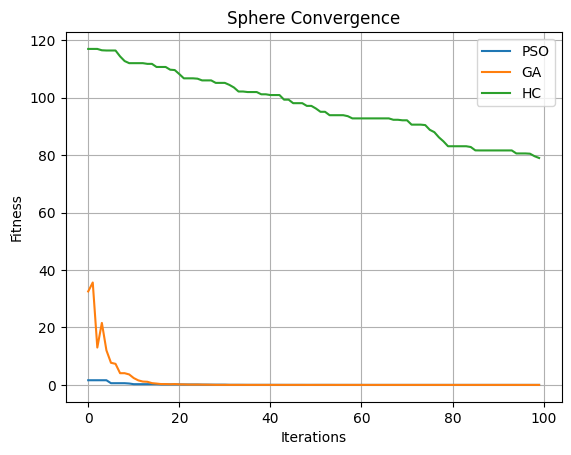

In [ ]:
min_len = min(len(pso_sphere_hist), len(ga_sphere_hist), len(hc_sphere_hist))

plt.plot(pso_sphere_hist[:min_len], label="PSO")
plt.plot(ga_sphere_hist[:min_len], label="GA")
plt.plot(hc_sphere_hist[:min_len], label="HC")

plt.title("Sphere Convergence")
plt.xlabel("Iterations")
plt.ylabel("Fitness")
plt.legend()
plt.grid()
plt.show()

In [ ]:
optimizer = ps.single.GlobalBestPSO(
    n_particles=30,
    dimensions=10,
    options={'c1':0.5,'c2':0.3,'w':0.9}
)

cost_ras_pso, _ = optimizer.optimize(rastrigin_pso, iters=100)
pso_ras_hist = optimizer.cost_history

print("PSO Rastrigin:", cost_ras_pso)

2026-04-28 08:28:11,661 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|100/100, best_cost=6.98
2026-04-28 08:28:11,768 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 6.984616348950553, best pos: [-3.44466421e-04  1.00172844e+00 -1.47984256e-03  9.88703279e-01
  9.93909452e-01  9.97410845e-01 -6.39979603e-04  9.93136120e-01
  9.93684876e-01  9.94157750e-01]


PSO Rastrigin: 6.984616348950553


In [ ]:
def eval_rastrigin(ind):
    return (rastrigin(np.array(ind)),)

toolbox.register("evaluate", eval_rastrigin)

population = toolbox.population(n=50)
ga_ras_hist = []

for gen in range(100):
    offspring = algorithms.varAnd(population, toolbox, cxpb=0.7, mutpb=0.2)
    fits = list(map(toolbox.evaluate, offspring))

    for fit, ind in zip(fits, offspring):
        ind.fitness.values = fit

    population = toolbox.select(offspring, k=len(population))

    best = tools.selBest(population, 1)[0]
    ga_ras_hist.append(best.fitness.values[0])

print("GA Rastrigin:", min(ga_ras_hist))

GA Rastrigin: 8.378924844884125


In [ ]:
_, best_ras_hc, hc_ras_hist = hill_climbing(rastrigin)
print("HC Rastrigin:", best_ras_hc)

HC Rastrigin: 92.69216224871477


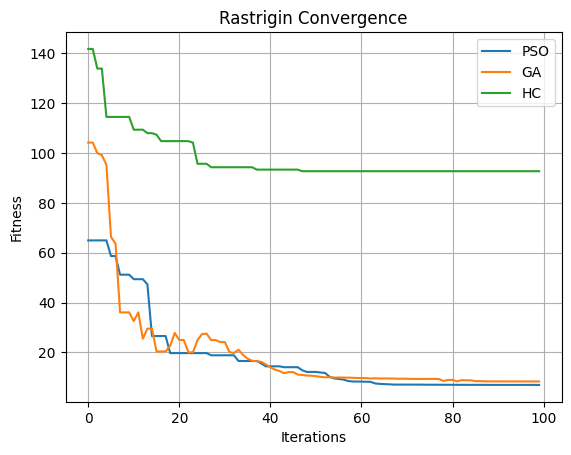

In [ ]:
min_len = min(len(pso_ras_hist), len(ga_ras_hist), len(hc_ras_hist))

plt.plot(pso_ras_hist[:min_len], label="PSO")
plt.plot(ga_ras_hist[:min_len], label="GA")
plt.plot(hc_ras_hist[:min_len], label="HC")

plt.title("Rastrigin Convergence")
plt.xlabel("Iterations")
plt.ylabel("Fitness")
plt.legend()
plt.grid()
plt.show()

In [ ]:
data = {
    "Function": ["Sphere", "Rastrigin"],
    "PSO": [min(pso_sphere_hist), min(pso_ras_hist)],
    "GA": [min(ga_sphere_hist), min(ga_ras_hist)],
    "HC": [min(hc_sphere_hist), min(hc_ras_hist)]
}

df = pd.DataFrame(data)
print(df)

    Function       PSO        GA         HC
0     Sphere  0.000019  0.002043  79.028947
1  Rastrigin  6.984616  8.378925  92.692162


In [ ]:
runs = 30

pso_sphere_results = []
ga_sphere_results = []
hc_sphere_results = []

for i in range(runs):

    # PSO
    optimizer = ps.single.GlobalBestPSO(
        n_particles=30,
        dimensions=10,
        options={'c1':0.5,'c2':0.3,'w':0.9}
    )
    cost, _ = optimizer.optimize(sphere_pso, iters=100)
    pso_sphere_results.append(cost)

    # GA
    population = toolbox.population(n=50)

    for gen in range(100):
        offspring = algorithms.varAnd(population, toolbox, cxpb=0.7, mutpb=0.2)
        fits = [(sphere(np.array(ind)),) for ind in offspring]

        for fit, ind in zip(fits, offspring):
            ind.fitness.values = fit

        population = toolbox.select(offspring, k=len(population))

    best = tools.selBest(population, 1)[0]
    ga_sphere_results.append(best.fitness.values[0])

    # HC
    _, best_val, _ = hill_climbing(sphere)
    hc_sphere_results.append(best_val)

2026-04-28 08:28:12,223 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|100/100, best_cost=2.85e-5
2026-04-28 08:28:12,399 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 2.8510294114558625e-05, best pos: [ 4.92070944e-06 -3.65804896e-05  1.29110057e-03 -3.03975644e-03
 -6.64734154e-05 -2.09356909e-03 -6.63989169e-04 -1.66760121e-03
 -2.26034659e-03 -2.20985962e-03]
2026-04-28 08:28:12,640 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|100/100, best_cost=0.000134
2026-04-28 08:28:12,752 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.00013413958293213724, best pos: [-0.00095121  0.00651169 -0.00121401  0.00180641  0.00265852 -0.00170443
  0.00513355 -0.00183628  0.00162556 -0.00661477]
2026-04-28 08:28:12,887 - pyswarms.single.global_best - 

/tmp/ipykernel_725/1796605082.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


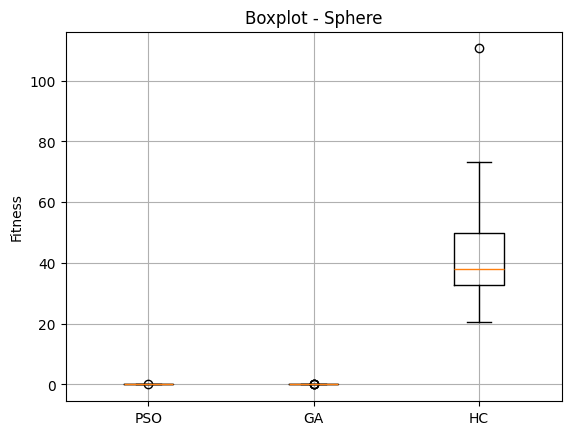

In [ ]:
plt.boxplot(
    [pso_sphere_results, ga_sphere_results, hc_sphere_results],
    labels=["PSO", "GA", "HC"]
)

plt.title("Boxplot - Sphere")
plt.ylabel("Fitness")
plt.grid(True)
plt.show()

In [ ]:
runs = 30

pso_ras_results = []
ga_ras_results = []
hc_ras_results = []

for i in range(runs):

    # PSO
    optimizer = ps.single.GlobalBestPSO(
        n_particles=30,
        dimensions=10,
        options={'c1':0.5,'c2':0.3,'w':0.9}
    )
    cost, _ = optimizer.optimize(rastrigin_pso, iters=100)
    pso_ras_results.append(cost)

    # GA
    population = toolbox.population(n=50)
    for gen in range(100):
        offspring = algorithms.varAnd(population, toolbox, cxpb=0.7, mutpb=0.2)
        fits = [(rastrigin(np.array(ind)),) for ind in offspring]

        for fit, ind in zip(fits, offspring):
            ind.fitness.values = fit

        population = toolbox.select(offspring, k=len(population))

    best = tools.selBest(population, 1)[0]
    ga_ras_results.append(best.fitness.values[0])

    # HC
    _, best_val, _ = hill_climbing(rastrigin)
    hc_ras_results.append(best_val)

2026-04-28 08:28:27,451 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|100/100, best_cost=3.01
2026-04-28 08:28:27,561 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 3.0083431765166893, best pos: [ 0.99213591  0.00454922  0.00432255 -0.00213359 -0.00213046  0.99935179
 -0.0028052   1.00023047  0.00223696  0.00137756]
2026-04-28 08:28:27,729 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|100/100, best_cost=8.96
2026-04-28 08:28:27,857 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 8.96000662999532, best pos: [4.33227208e-07 9.97173169e-01 9.93908072e-01 9.93955675e-01
 9.91336773e-01 9.94383096e-01 9.95291845e-01 9.94420180e-01
 9.93603996e-01 9.92858143e-01]
2026-04-28 08:28:28,021 - pyswarms.single.global_best - INFO - Optimize for 100 ite

/tmp/ipykernel_725/310546156.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


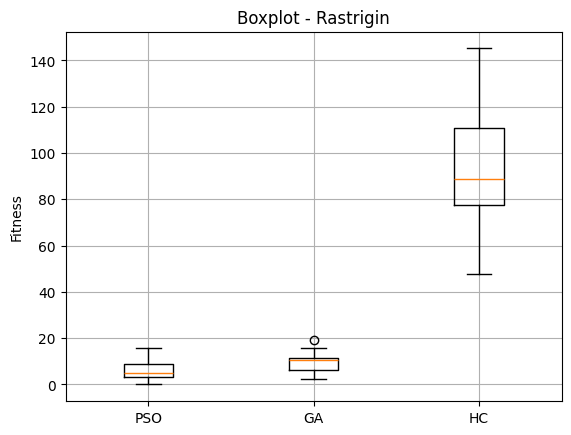

In [ ]:
plt.boxplot(
    [pso_ras_results, ga_ras_results, hc_ras_results],
    labels=["PSO", "GA", "HC"]
)

plt.title("Boxplot - Rastrigin")
plt.ylabel("Fitness")
plt.grid(True)
plt.show()